In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
!pip install -q mlflow dagshub

import dagshub
import mlflow

DAGSHUB_USER = 'gormo22'
REPO_NAME = 'ML-HousePricePrediction'

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=REPO_NAME, mlflow=True)
tracking_uri = f"https://dagshub.com/{DAGSHUB_USER}/{REPO_NAME}.mlflow"
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("House_Price_Prediction")
print("MLflow and DagsHub successfully connected.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=3d7723a0-7c13-43fd-bd5a-7146fed7b906&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=474e064e63bc1d654216ca5178742547c75728c1953ef4d8046b38e2cb319087




Accessing as gormo22

Initialized MLflow to track repo "gormo22/ML-HousePricePrediction"

Repository gormo22/ML-HousePricePrediction initialized!

MLflow and DagsHub successfully connected.


In [3]:
import warnings
import logging
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy.stats import skew

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor

import mlflow
import mlflow.sklearn

## Data Analysis

In [4]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

train_path = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv'
test_path = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
display(train_df.head())

Train data shape: (1460, 81)
Test data shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Columns with Missing Values:


,Missing_Count,Missing_Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


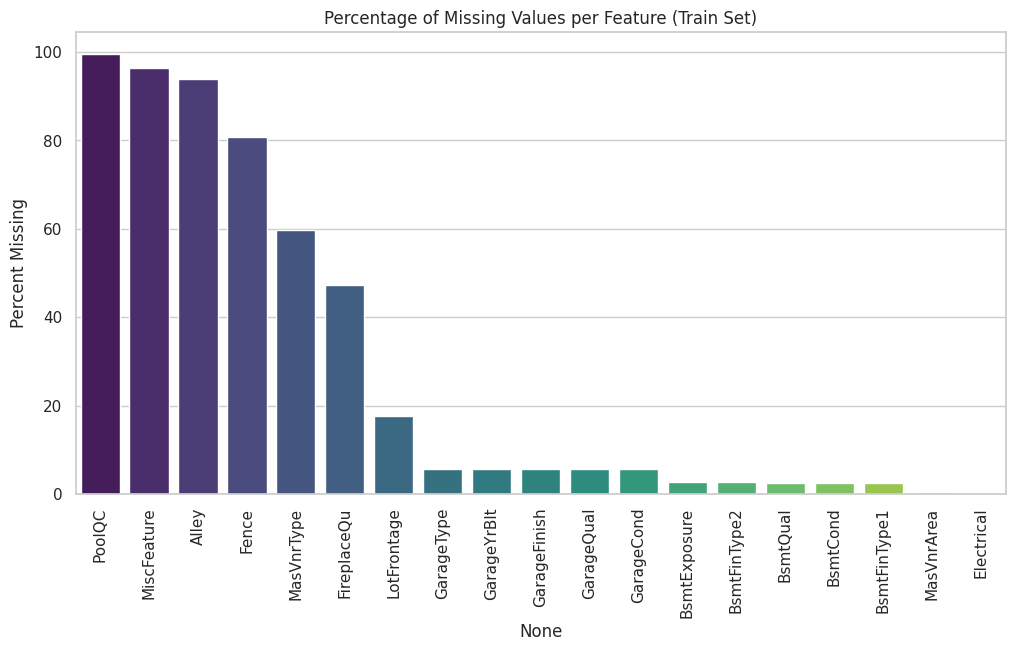

In [5]:
missing_data = train_df.isnull().sum()
missing_percentage = (missing_data / len(train_df)) * 100

missing_df = pd.DataFrame({'Missing_Count': missing_data, 'Missing_Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)

print("Columns with Missing Values:")
display(missing_df)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_df.index, y=missing_df['Missing_Percentage'], palette='viridis')
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values per Feature (Train Set)')
plt.ylabel('Percent Missing')
plt.show()

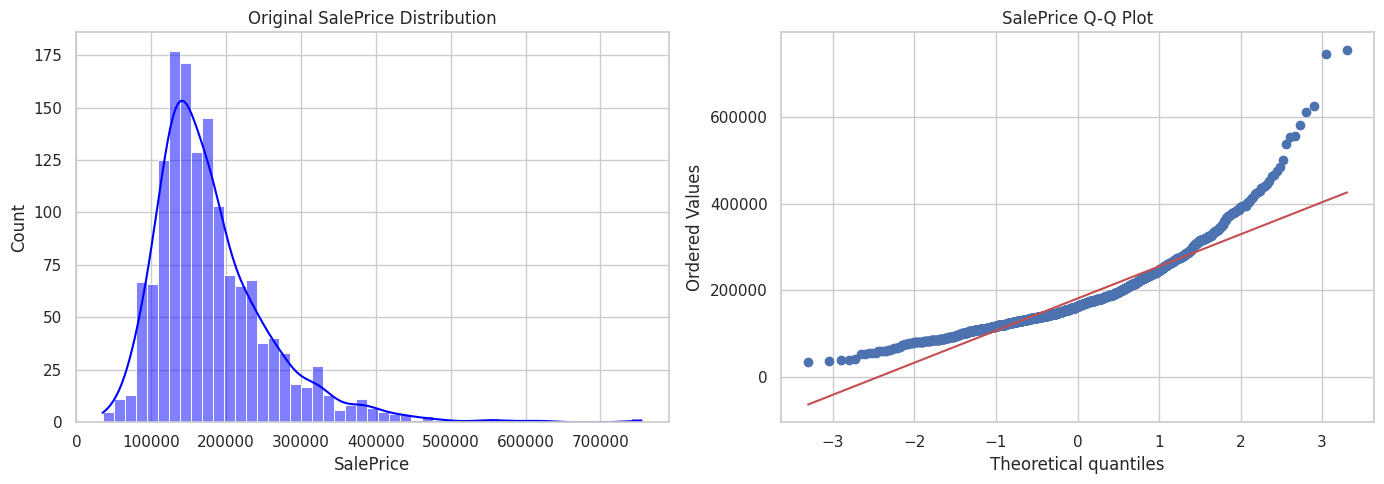

Skewness: 1.8829
Kurtosis: 6.5363


In [6]:
from scipy import stats

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df['SalePrice'], kde=True, color='blue')
plt.title('Original SalePrice Distribution')
plt.subplot(1, 2, 2)
stats.probplot(train_df['SalePrice'], plot=plt)
plt.title('SalePrice Q-Q Plot')
plt.tight_layout()
plt.show()

print(f"Skewness: {train_df['SalePrice'].skew():.4f}")
print(f"Kurtosis: {train_df['SalePrice'].kurt():.4f}")

## Data Cleaning 

In [7]:
features = pd.concat([
    train_df.drop(['Id', 'SalePrice'], axis=1),
    test_df.drop(['Id'], axis=1)
]).reset_index(drop=True)

cols_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']
features = features.drop(columns=cols_to_drop)

none_cols = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu'
]
for col in none_cols:
    features[col] = features[col].fillna('None')

zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2',
    'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in zero_cols:
    features[col] = features[col].fillna(0)

features['LotFrontage'] = features.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional', 'Utilities']
for col in mode_cols:
    features[col] = features[col].fillna(features[col].mode()[0])

In [8]:
y_train = np.log1p(train_df['SalePrice'])
print(f"Total missing values remaining: {features.isnull().sum().sum()}")

Total missing values remaining: 0


## Feature Engineering

In [9]:
features['MSSubClass'] = features['MSSubClass'].astype(str)
features['MoSold'] = features['MoSold'].astype(str)
features['YrSold'] = features['YrSold'].astype(str)

quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
qual_cols = ['FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
             'ExterQual', 'ExterCond', 'HeatingQC', 'KitchenQual']

for col in qual_cols:
    features[col] = features[col].map(quality_map).fillna(0).astype(int)

exposure_map = {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
features['BsmtExposure'] = features['BsmtExposure'].map(exposure_map).fillna(0).astype(int)

fin_map = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
features['BsmtFinType1'] = features['BsmtFinType1'].map(fin_map).fillna(0).astype(int)
features['BsmtFinType2'] = features['BsmtFinType2'].map(fin_map).fillna(0).astype(int)

def engineer_features(df):
    df = df.copy()
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBaths'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
    df['TotalPorchArea'] = df['WoodDeckSF'] + df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
    df['HouseAge'] = df['YrSold'].astype(int) - df['YearBuilt']
    df['RemodelAge'] = df['YrSold'].astype(int) - df['YearRemodAdd']
    df['GarageAge'] = df['YrSold'].astype(int) - df['GarageYrBlt']
    df['HouseAge'] = df['HouseAge'].apply(lambda x: x if x > 0 else 0)
    df['RemodelAge'] = df['RemodelAge'].apply(lambda x: x if x > 0 else 0)
    df['TotalQuality'] = df['OverallQual'] + df['OverallCond']
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBsmt'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    
    return df

features = engineer_features(features)
cat_cols = features.select_dtypes(include=['object']).columns
num_cols = features.drop(columns=cat_cols)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_cat = ohe.fit_transform(features[cat_cols])

encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=ohe.get_feature_names_out(cat_cols)
)

features_encoded = pd.concat(
    [num_cols.reset_index(drop=True),
     encoded_cat_df.reset_index(drop=True)],
    axis=1
)

X_train_clean = features_encoded.iloc[:len(y_train), :]
X_test_clean = features_encoded.iloc[len(y_train):, :]

print(f"Cleaned Train shape: {X_train_clean.shape}")
print(f"Cleaned Test shape: {X_test_clean.shape}")

Cleaned Train shape: (1460, 271)
Cleaned Test shape: (1459, 271)


In [10]:
train_nans = X_train_clean.isna().sum().sum()
test_nans = X_test_clean.isna().sum().sum()

print(f"Total NaNs in Train: {train_nans}")
print(f"Total NaNs in Test: {test_nans}")

train_cats = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
test_cats = X_test_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Categorical columns left in Train: {len(train_cats)} {train_cats}")
print(f"Categorical columns left in Test: {len(test_cats)} {test_cats}")

Total NaNs in Train: 0
Total NaNs in Test: 0
Categorical columns left in Train: 0 []
Categorical columns left in Test: 0 []


## Feature Selection

Dropped 44 highly correlated features.
Calculating dynamic feature importances...

Dynamic Selection Threshold: 96.0% of total importance
Number of features kept: 37 (out of 227)
Final Train shape: (1460, 37)


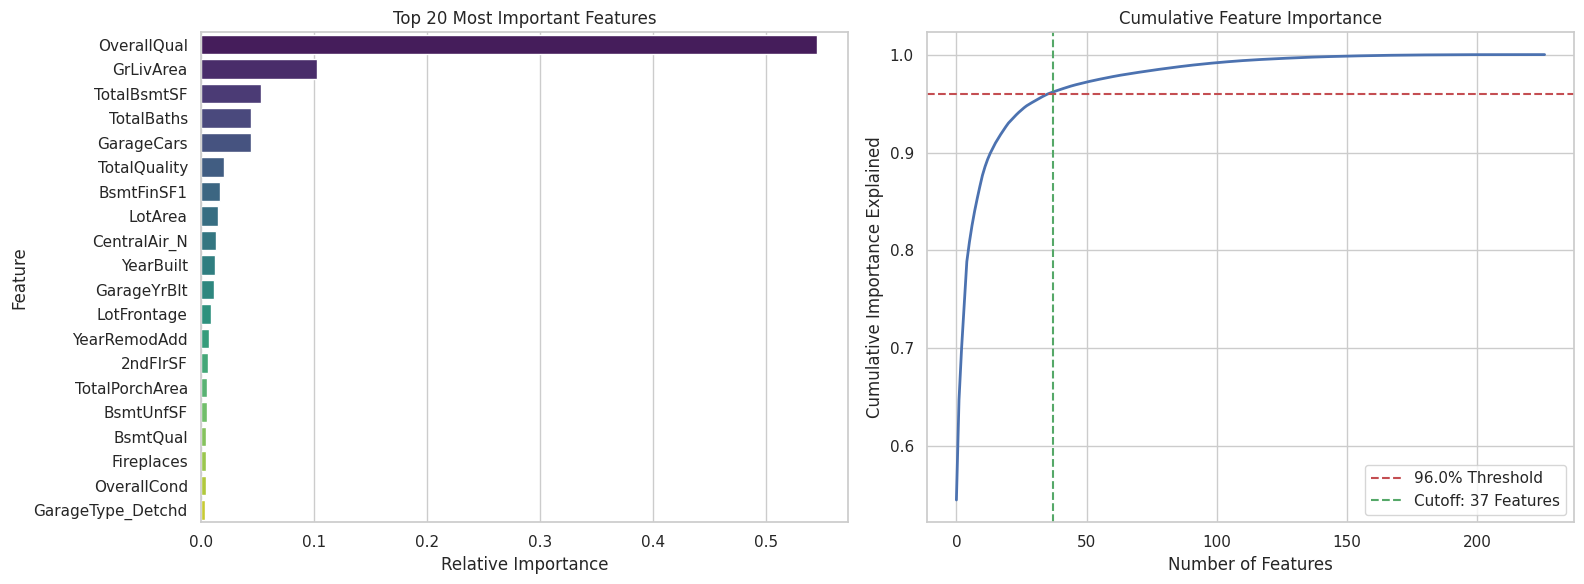

In [11]:
corr_matrix = X_train_clean.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.80)]
X_train_reduced = X_train_clean.drop(columns=to_drop_corr)
X_test_reduced = X_test_clean.drop(columns=to_drop_corr)

print(f"Dropped {len(to_drop_corr)} highly correlated features.")
print("Calculating dynamic feature importances...")
rf = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf.fit(X_train_reduced, y_train)

feature_importances = pd.DataFrame({
    'Feature': X_train_reduced.columns,
    'Importance': rf.feature_importances_
})

feature_importances = feature_importances.sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importances['Cumulative_Importance'] = feature_importances['Importance'].cumsum()

threshold = 0.96
num_features_to_keep = np.where(feature_importances['Cumulative_Importance'] >= threshold)[0][0] + 1
selected_features = feature_importances['Feature'].head(num_features_to_keep).tolist()

X_train_final = X_train_reduced[selected_features]
X_test_final = X_test_reduced[selected_features]

print(f"\nDynamic Selection Threshold: {threshold*100}% of total importance")
print(f"Number of features kept: {num_features_to_keep} (out of {len(X_train_reduced.columns)})")
print(f"Final Train shape: {X_train_final.shape}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x='Importance', y='Feature', 
    data=feature_importances.head(20), 
    ax=axes[0], palette='viridis'
)
axes[0].set_title('Top 20 Most Important Features')
axes[0].set_xlabel('Relative Importance')

axes[1].plot(
    feature_importances.index, 
    feature_importances['Cumulative_Importance'], 
    color='b', linewidth=2
)
axes[1].axhline(y=threshold, color='r', linestyle='--', label=f'{threshold*100}% Threshold')
axes[1].axvline(x=num_features_to_keep, color='g', linestyle='--', label=f'Cutoff: {num_features_to_keep} Features')
axes[1].set_title('Cumulative Feature Importance')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance Explained')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Handling skewed features

In [12]:
X_train_final = X_train_final.copy()
X_test_final = X_test_final.copy()

continuous_features = X_train_final.select_dtypes(include=[np.number]).columns
skewed_feats = X_train_final[continuous_features].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness_df = pd.DataFrame({'Skewness': skewed_feats})

highly_skewed = skewness_df[abs(skewness_df['Skewness']) > 0.75].index

print(f"Found {len(highly_skewed)} highly skewed features out of {len(continuous_features)} continuous features.")
print("\nTop Skewed Features Before Transformation:")
print(skewness_df.loc[highly_skewed].head())

for col in highly_skewed:
    X_train_final[col] = np.log1p(X_train_final[col])
    X_test_final[col] = np.log1p(X_test_final[col])

print("\nFeature skewness successfully corrected.")
print("Highly Skewed Features:", highly_skewed.tolist())

Found 23 highly skewed features out of 37 continuous features.

Top Skewed Features Before Transformation:
                   Skewness
LotArea           12.195142
MSZoning_C (all)  11.958549
KitchenAbvGr       4.483784
PavedDrive_N       3.645259
CentralAir_N       3.526757

Feature skewness successfully corrected.
Highly Skewed Features: ['LotArea', 'MSZoning_C (all)', 'KitchenAbvGr', 'PavedDrive_N', 'CentralAir_N', 'EnclosedPorch', 'MasVnrArea', 'OpenPorchSF', 'LotFrontage', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', 'ExterCond', 'GrLivArea', 'BsmtExposure', 'TotalPorchArea', 'GarageType_Detchd', 'BsmtUnfSF', 'ExterQual', '2ndFlrSF', 'BsmtQual', 'MSZoning_RL', 'GarageYrBlt']


## Linear models: Ridge and Lasso Regression

 Training & Tuning Ridge_Regression:
Tested Alphas: [1.0, 10.0, 30.0, 50.0, 100.0, 200.0, 500.0]
Best Alpha found: 10.0
SCORES:
TRAIN RMSE: 0.1297  |  TRAIN R2: 0.8930
VAL RMSE:   0.1358  |  VAL R2:   0.8816

Gap (Val - Train): 0.0061


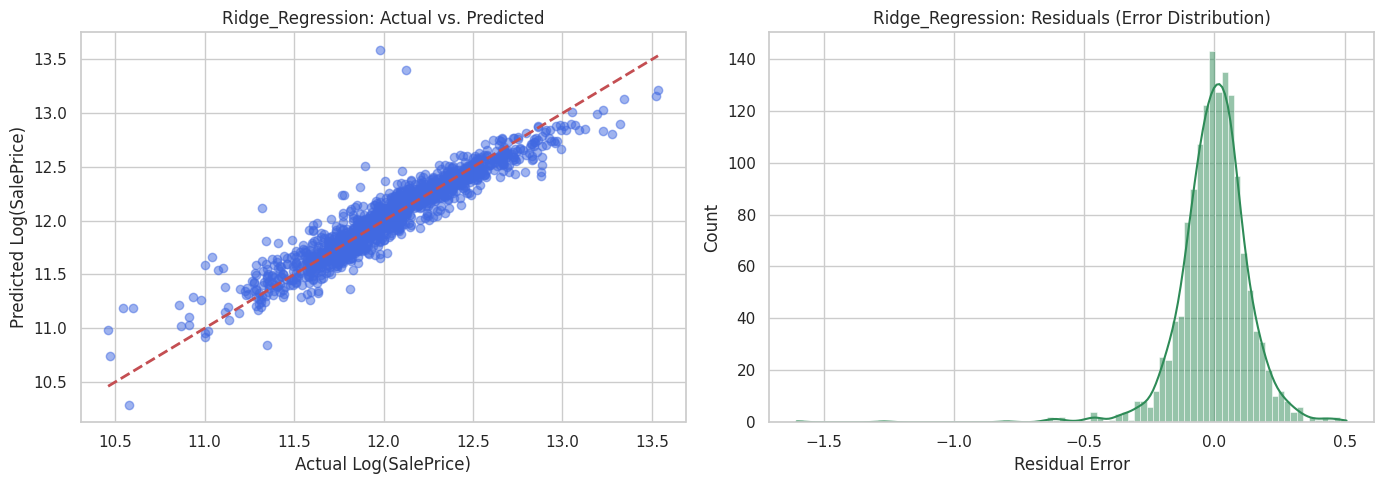

🏃 View run Ridge_Regression_HyperTuning at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2/runs/2207040f32574a55be53ad47b6eec0f2
🧪 View experiment at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2
 Training & Tuning Lasso_Regression:
Tested Alphas: [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
Best Alpha found: 0.001
SCORES:
TRAIN RMSE: 0.1299  |  TRAIN R2: 0.8928
VAL RMSE:   0.1356  |  VAL R2:   0.8819

Gap (Val - Train): 0.0057


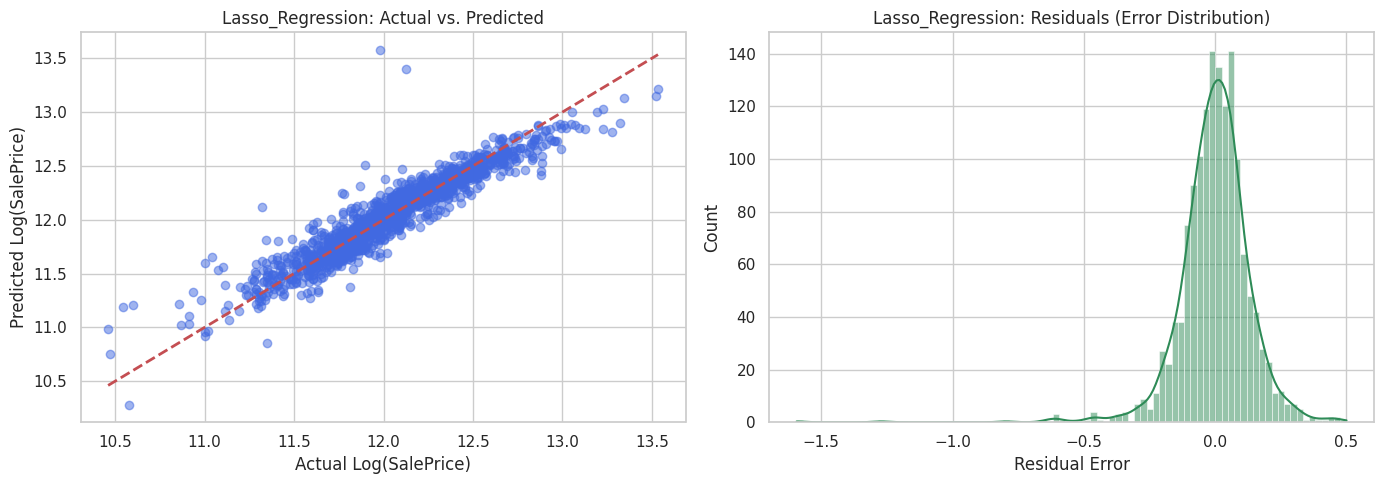

🏃 View run Lasso_Regression_HyperTuning at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2/runs/7dba285c8fe04ad88934999547443f85
🧪 View experiment at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2
All linear models trained, tuned, and logged to MLflow


In [13]:
warnings.filterwarnings('ignore') 
logging.getLogger("mlflow").setLevel(logging.ERROR)

mlflow.set_experiment("House_Price_Prediction")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)

models_to_test = {
    "Ridge_Regression": {
        "model": Ridge(random_state=42),
        "params": {"alpha": [1.0, 10.0, 30.0, 50.0, 100.0, 200.0, 500.0]} 
    },
    "Lasso_Regression": {
        "model": Lasso(random_state=42, max_iter=10000),
        "params": {"alpha": [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]} 
    }
}

for model_name, config in models_to_test.items():
    print(f" Training & Tuning {model_name}:")
    
    with mlflow.start_run(run_name=f"{model_name}_HyperTuning"):
        
        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring='neg_root_mean_squared_error',
            cv=kf,
            n_jobs=-1,
            return_train_score=True
        )
        
        grid.fit(X_train_scaled, y_train)
        best_model = grid.best_estimator_
        best_rmse = -grid.best_score_
        best_alpha = grid.best_params_['alpha']
        cv_preds = cross_val_predict(best_model, X_train_scaled, y_train, cv=kf)        
        cv_r2 = r2_score(y_train, cv_preds)
        
        best_idx = grid.best_index_
        train_rmse = -grid.cv_results_['mean_train_score'][best_idx]
        train_preds = best_model.predict(X_train_scaled)        
        train_r2 = r2_score(y_train, train_preds)
        
        print(f"Tested Alphas: {config['params']['alpha']}")
        print(f"Best Alpha found: {best_alpha}")
        
        print("SCORES:")
        print(f"TRAIN RMSE: {train_rmse:.4f}  |  TRAIN R2: {train_r2:.4f}")
        print(f"VAL RMSE:   {best_rmse:.4f}  |  VAL R2:   {cv_r2:.4f}")
        
        diff = best_rmse - train_rmse
        print(f"\nGap (Val - Train): {diff:.4f}")
        
        mlflow.log_param("tested_alphas", str(config["params"]["alpha"]))
        mlflow.log_param("best_alpha", best_alpha)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("cv_rmse", best_rmse)
        mlflow.log_metric("cv_r2", cv_r2)
        mlflow.sklearn.log_model(best_model, f"{model_name}_model")
        
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].scatter(y_train, cv_preds, alpha=0.5, color='royalblue')
        axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
        axes[0].set_title(f"{model_name}: Actual vs. Predicted")
        axes[0].set_xlabel("Actual Log(SalePrice)")
        axes[0].set_ylabel("Predicted Log(SalePrice)")
        residuals = y_train - cv_preds
        sns.histplot(residuals, kde=True, ax=axes[1], color='seagreen')
        axes[1].set_title(f"{model_name}: Residuals (Error Distribution)")
        axes[1].set_xlabel("Residual Error")
        
        plt.tight_layout()
        mlflow.log_figure(fig, f"{model_name}_evaluation_plots.png")
        plt.show()

print("All linear models trained, tuned, and logged to MLflow")

## Tree Models: Single Decision Tree, Random Forest and Gradient Boosting.

 Training & Tuning Single_Decision_Tree:
Best Parameters Found:
  - max_depth: 6
  - min_samples_leaf: 5
  - min_samples_split: 5
SCORES:
TRAIN RMSE: 0.1386  |  TRAIN R2: 0.8783
VAL RMSE:   0.1963  |  VAL R2:   0.7571

Gap (Val - Train): 0.0577


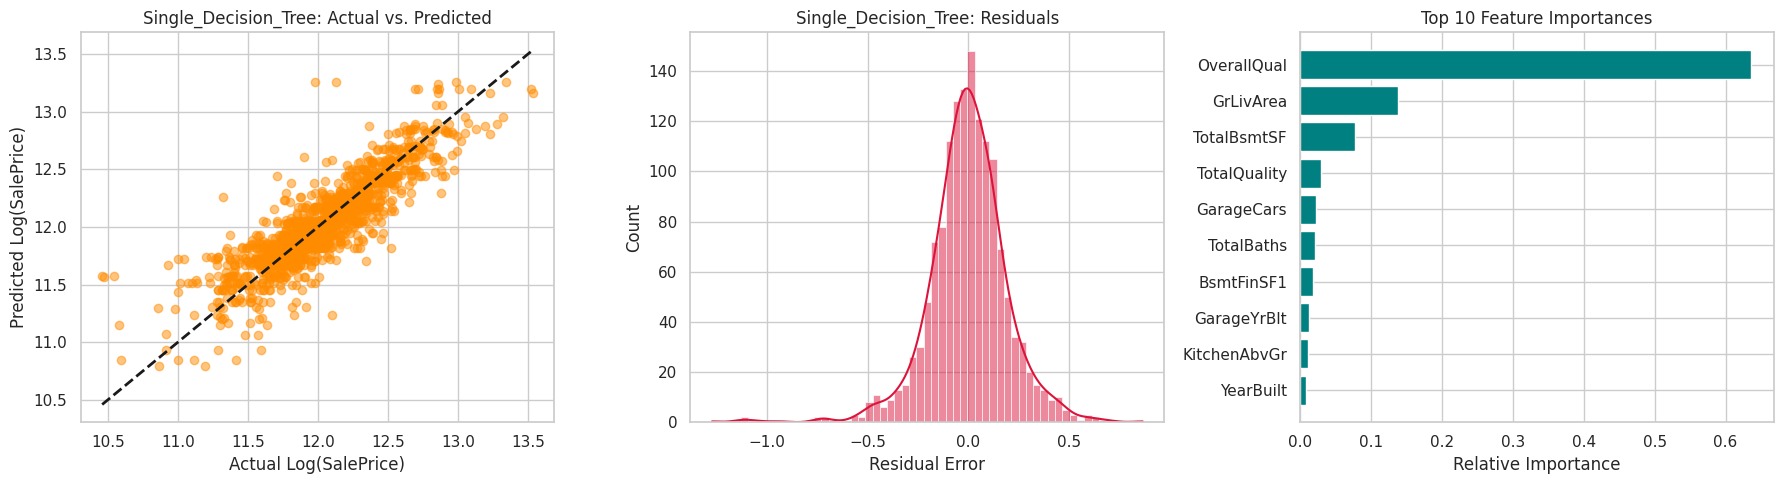

🏃 View run Single_Decision_Tree_HyperTuning at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2/runs/6bbb47dd64cd4acabecf3f3d78917eae
🧪 View experiment at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2
 Training & Tuning Random_Forest:
Best Parameters Found:
  - max_depth: 10
  - max_features: 0.5
  - min_samples_leaf: 4
  - min_samples_split: 10
  - n_estimators: 150
SCORES:
TRAIN RMSE: 0.0928  |  TRAIN R2: 0.9469
VAL RMSE:   0.1383  |  VAL R2:   0.8787

Gap (Val - Train): 0.0455


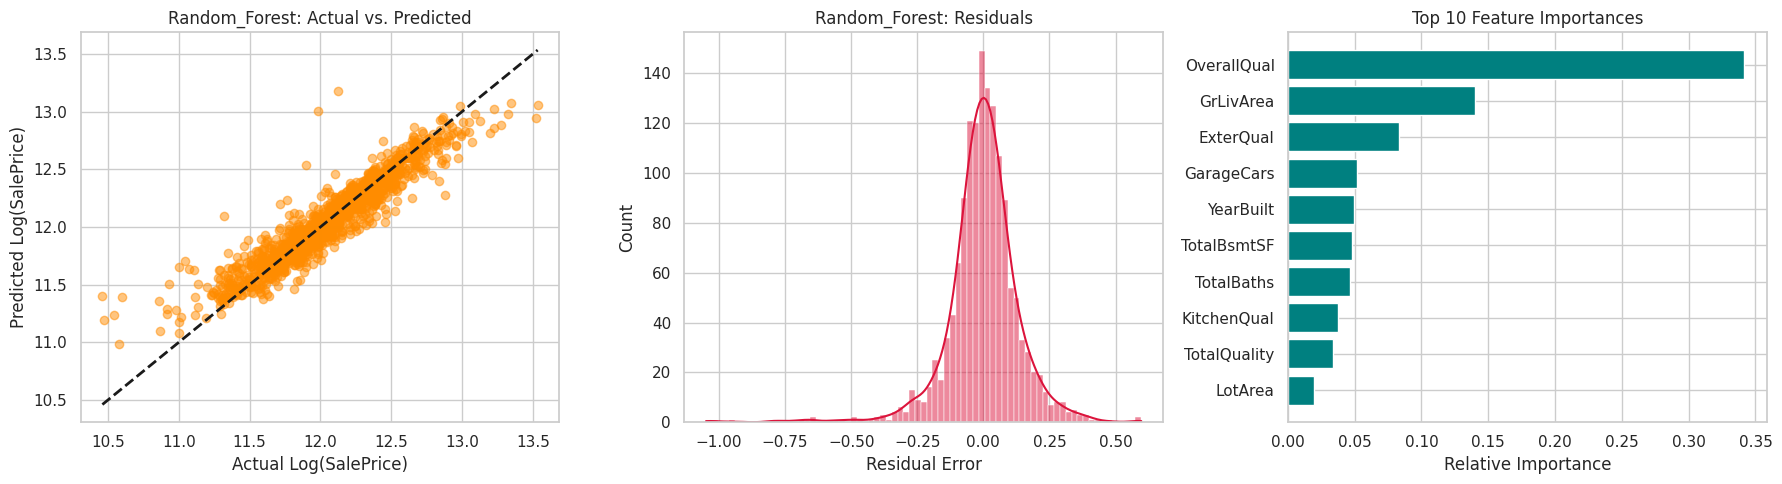

🏃 View run Random_Forest_HyperTuning at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2/runs/f548158680f44753aa4afad829821079
🧪 View experiment at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2
 Training & Tuning Gradient_Boosting:
Best Parameters Found:
  - learning_rate: 0.04
  - max_depth: 2
  - max_features: 0.5
  - min_samples_leaf: 15
  - min_samples_split: 30
  - n_estimators: 200
  - subsample: 0.6
SCORES:
TRAIN RMSE: 0.1167  |  TRAIN R2: 0.9132
VAL RMSE:   0.1342  |  VAL R2:   0.8858

Gap (Val - Train): 0.0175


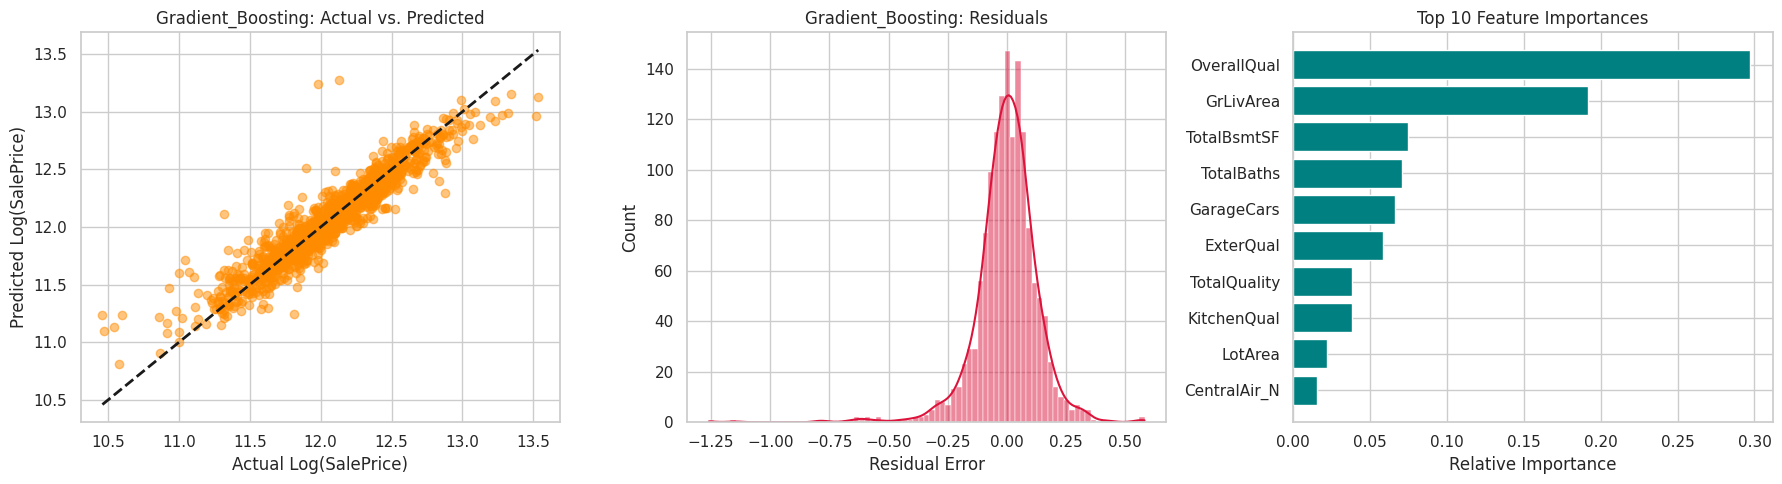

🏃 View run Gradient_Boosting_HyperTuning at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2/runs/94fae9eb81b84f22ade22e32542736e2
🧪 View experiment at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2
All tree models trained, tuned and logged to MLflow


In [14]:
warnings.filterwarnings('ignore') 
logging.getLogger("mlflow").setLevel(logging.ERROR)

mlflow.set_experiment("House_Price_Prediction")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

tree_models_to_test = {
    "Single_Decision_Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [2, 3, 6],
            "min_samples_split": [5, 10],
            "min_samples_leaf": [3, 5]
        }
    },
    "Random_Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [150, 250],
            "max_depth": [6, 8, 10], 
            "min_samples_split": [10, 15, 20], 
            "min_samples_leaf": [4, 8], 
            "max_features": ['sqrt', 0.5] 
        }
    },
    "Gradient_Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [100, 150, 200],
            "learning_rate": [0.02, 0.04], 
            "max_depth": [2],  
            "min_samples_split": [30, 40],
            "min_samples_leaf": [15, 20], 
            "subsample": [0.6, 0.7], 
            "max_features": ['sqrt', 0.5, 0.8] 
        }
    }
}

for model_name, config in tree_models_to_test.items():
    print(f" Training & Tuning {model_name}:")
    
    with mlflow.start_run(run_name=f"{model_name}_HyperTuning"):
        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring='neg_root_mean_squared_error',
            cv=kf,
            n_jobs=-1,
            return_train_score=True
        )
        
        grid.fit(X_train_final, y_train)
        best_model = grid.best_estimator_
        
        best_rmse = -grid.best_score_
        cv_preds = cross_val_predict(best_model, X_train_final, y_train, cv=kf)
        cv_r2 = r2_score(y_train, cv_preds)

        best_idx = grid.best_index_
        train_rmse = -grid.cv_results_['mean_train_score'][best_idx]
        train_preds = best_model.predict(X_train_final)
        train_r2 = r2_score(y_train, train_preds)
        
        print(f"Best Parameters Found:")
        for param, value in grid.best_params_.items():
            print(f"  - {param}: {value}")
            
        print("SCORES:")
        print(f"TRAIN RMSE: {train_rmse:.4f}  |  TRAIN R2: {train_r2:.4f}")
        print(f"VAL RMSE:   {best_rmse:.4f}  |  VAL R2:   {cv_r2:.4f}")
        
        diff = best_rmse - train_rmse
        print(f"\nGap (Val - Train): {diff:.4f}")
        
        mlflow.log_params(grid.best_params_)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("cv_rmse", best_rmse)
        mlflow.log_metric("cv_r2", cv_r2)
        
        mlflow.sklearn.log_model(best_model, f"{model_name}_model")
        
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        axes[0].scatter(y_train, cv_preds, alpha=0.5, color='darkorange')
        axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
        axes[0].set_title(f"{model_name}: Actual vs. Predicted")
        axes[0].set_xlabel("Actual Log(SalePrice)")
        axes[0].set_ylabel("Predicted Log(SalePrice)")
        
        residuals = y_train - cv_preds
        sns.histplot(residuals, kde=True, ax=axes[1], color='crimson')
        axes[1].set_title(f"{model_name}: Residuals")
        axes[1].set_xlabel("Residual Error")
        
        importances = best_model.feature_importances_
        indices = np.argsort(importances)[-10:]
        
        axes[2].barh(range(len(indices)), importances[indices], color='teal', align='center')
        axes[2].set_yticks(range(len(indices)))
        axes[2].set_yticklabels([X_train_final.columns[i] for i in indices])
        axes[2].set_title("Top 10 Feature Importances")
        axes[2].set_xlabel("Relative Importance")
        
        plt.tight_layout()
        mlflow.log_figure(fig, f"{model_name}_evaluation_plots.png")
        plt.show()

print("All tree models trained, tuned and logged to MLflow")

## XGBoost

Starting Randomized Search...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters Found: {'subsample': 0.8, 'reg_lambda': 2.0, 'reg_alpha': 0.0, 'n_estimators': 600, 'min_child_weight': 15, 'max_depth': 4, 'learning_rate': 0.02, 'gamma': 0.1, 'colsample_bytree': 0.5}
SCORES:
TRAIN RMSE: 0.1015  |  TRAIN R2: 0.9345
VAL RMSE:   0.1320  |  VAL R2:   0.8894


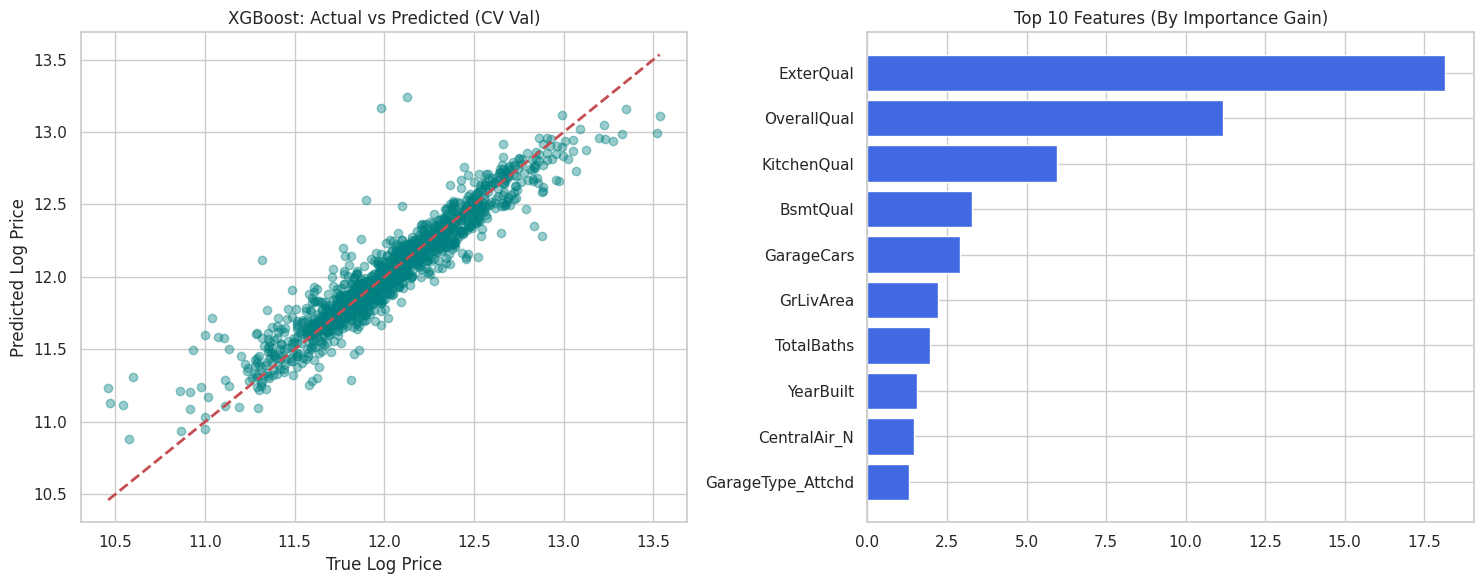

🏃 View run XGBoost_RandomSearch at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2/runs/aa3e49b6279b4103ba1c60e7d77aa990
🧪 View experiment at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2

XGBoost complete.


In [15]:
model_name = "XGBoost_RandomSearch"
mlflow.set_experiment("House_Price_Prediction")

with mlflow.start_run(run_name=model_name):
    
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
    
    param_dist = {
        'n_estimators': [300, 400, 600],
        'learning_rate': [0.01, 0.02, 0.03],
        'max_depth': [4, 5, 6],
        'min_child_weight': [5, 10, 15],
        'subsample': [0.6, 0.7, 0.8],
        'colsample_bytree': [0.5, 0.6, 0.7],
        'gamma': [0.1, 0.2, 0.5],
        'reg_alpha': [0.0, 0.1, 0.5, 1.0],
        'reg_lambda': [1.0, 2.0, 5.0, 10.0]
    }

    print(f"Starting Randomized Search...")
    
    random_search = RandomizedSearchCV(
        estimator=xgb_model,
        param_distributions=param_dist,
        n_iter=40, 
        cv=kf,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True 
    )
    
    random_search.fit(X_train_final, y_train)
    best_xgb = random_search.best_estimator_
    best_idx = random_search.best_index_
    
    train_rmse = -random_search.cv_results_['mean_train_score'][best_idx]
    train_preds = best_xgb.predict(X_train_final)
    train_r2 = r2_score(y_train, train_preds)

    best_rmse = -random_search.best_score_
    cv_preds = cross_val_predict(best_xgb, X_train_final, y_train, cv=kf)
    cv_r2 = r2_score(y_train, cv_preds)

    print(f"\nBest Parameters Found: {random_search.best_params_}")
    print("SCORES:")
    print(f"TRAIN RMSE: {train_rmse:.4f}  |  TRAIN R2: {train_r2:.4f}")
    print(f"VAL RMSE:   {best_rmse:.4f}  |  VAL R2:   {cv_r2:.4f}")
    
    diff = best_rmse - train_rmse
    
    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse", best_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("val_r2", cv_r2)
    mlflow.xgboost.log_model(best_xgb, "model")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    axes[0].scatter(y_train, cv_preds, alpha=0.4, color='teal')
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_title(f"XGBoost: Actual vs Predicted (CV Val)")
    axes[0].set_xlabel("True Log Price")
    axes[0].set_ylabel("Predicted Log Price")

    importance = best_xgb.get_booster().get_score(importance_type='gain')
    if importance:
        importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)[:10]
        labels, values = zip(*importance)
        axes[1].barh(labels, values, color='royalblue')
        axes[1].invert_yaxis()
        axes[1].set_title("Top 10 Features (By Importance Gain)")
    else:
        axes[1].set_title("No features retained")

    plt.tight_layout()
    mlflow.log_figure(fig, "fast_xgb_results.png")
    plt.show()

print("\nXGBoost complete.")

## LightGB Model

Starting LightGBM Random Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best LightGBM Params: {'reg_lambda': 5.0, 'reg_alpha': 0.1, 'num_leaves': 15, 'n_estimators': 900, 'min_child_weight': 0.1, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.01, 'feature_fraction': 0.6, 'bagging_freq': 3, 'bagging_fraction': 0.7}
SCORES:
TRAIN RMSE: 0.0903  |  TRAIN R2: 0.9464
VAL RMSE:   0.1299  |  VAL R2:   0.8927

Gap (Val - Train): 0.0395


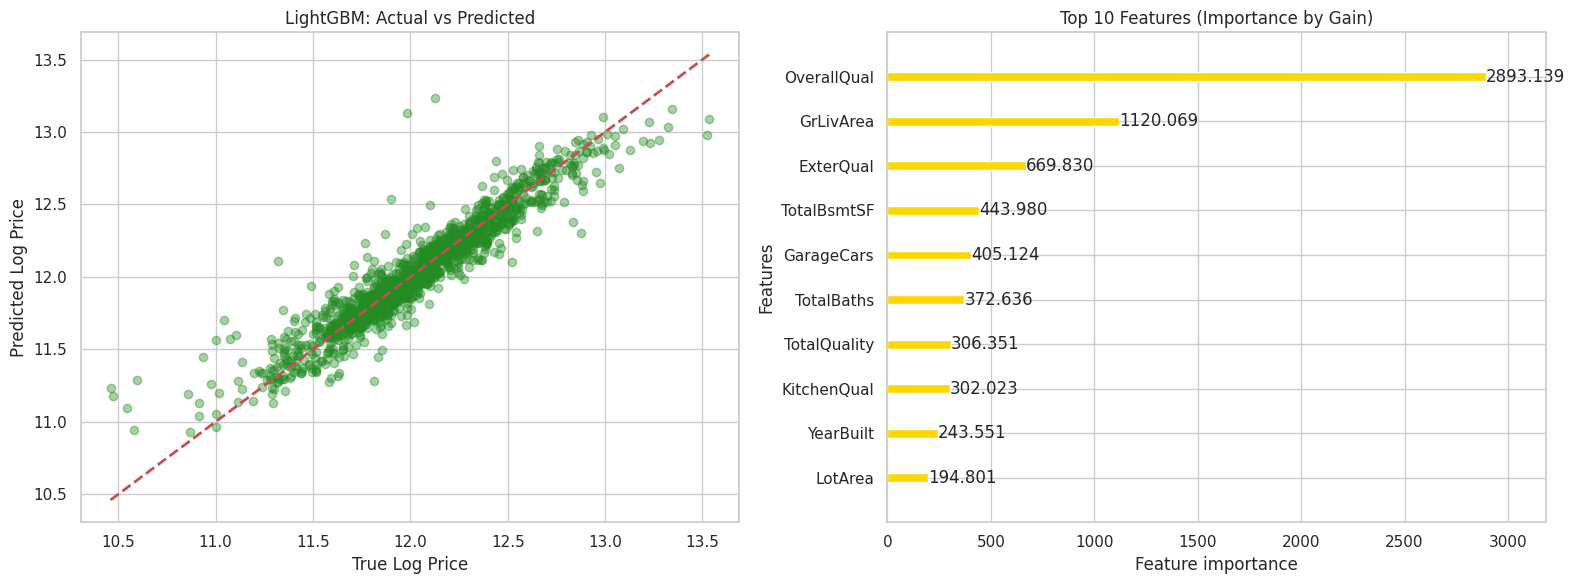

🏃 View run LightGBM at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2/runs/1312225b45d647eb891a075e16b1e360
🧪 View experiment at: https://dagshub.com/gormo22/ML-HousePricePrediction.mlflow/#/experiments/2

LightGBM tuning and logging complete.


In [16]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import mlflow

model_name = "LightGBM"
mlflow.set_experiment("House_Price_Prediction")

with mlflow.start_run(run_name=model_name):

    lgbm_model = lgb.LGBMRegressor(random_state=42, verbosity=-1)

    param_dist = {
        'n_estimators': [400, 600, 900],
        'learning_rate': [0.01, 0.02, 0.03],
        'num_leaves': [15, 31, 40], 
        'max_depth': [-1, 3, 4, 5],
        'min_child_samples': [10, 20, 40],
        'min_child_weight': [1e-3, 1e-2, 0.1],
        'feature_fraction': [0.6, 0.7, 0.8],
        'bagging_fraction': [0.6, 0.7, 0.8],
        'bagging_freq': [1, 3, 5],
        'reg_alpha': [0.0, 0.1, 0.5, 1.0],
        'reg_lambda': [0.5, 1.0, 2.0, 5.0]
    }

    print(f"Starting LightGBM Random Search...")
    
    random_search = RandomizedSearchCV(
        estimator=lgbm_model,
        param_distributions=param_dist,
        n_iter=50, 
        cv=kf,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )
    
    random_search.fit(X_train_final, y_train)
    best_lgbm = random_search.best_estimator_
    best_idx = random_search.best_index_

    train_rmse = -random_search.cv_results_['mean_train_score'][best_idx]
    train_preds = best_lgbm.predict(X_train_final)
    train_r2 = r2_score(y_train, train_preds)

    best_rmse = -random_search.best_score_
    cv_preds = cross_val_predict(best_lgbm, X_train_final, y_train, cv=kf)
    cv_r2 = r2_score(y_train, cv_preds)

    print(f"\nBest LightGBM Params: {random_search.best_params_}")
    print("SCORES:")
    print(f"TRAIN RMSE: {train_rmse:.4f}  |  TRAIN R2: {train_r2:.4f}")
    print(f"VAL RMSE:   {best_rmse:.4f}  |  VAL R2:   {cv_r2:.4f}")
    print(f"\nGap (Val - Train): {(best_rmse - train_rmse):.4f}")

    mlflow.log_params(random_search.best_params_)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("cv_rmse", best_rmse)
    mlflow.log_metric("cv_r2", cv_r2)
    mlflow.lightgbm.log_model(best_lgbm, "model")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].scatter(y_train, cv_preds, alpha=0.4, color='forestgreen')
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
    axes[0].set_title(f"LightGBM: Actual vs Predicted")
    axes[0].set_xlabel("True Log Price")
    axes[0].set_ylabel("Predicted Log Price")
    lgb.plot_importance(best_lgbm, max_num_features=10, ax=axes[1], importance_type='gain', color='gold')
    axes[1].set_title("Top 10 Features (Importance by Gain)")

    plt.tight_layout()
    mlflow.log_figure(fig, "lgbm_performance_plots.png")
    plt.show()

print("\nLightGBM tuning and logging complete.")